Using node features from Data/spaformer_prepared/latent_refined.npy
nodes: 3639 features: 256 hyper-edges: 3639
Leiden clusters: 7
SimpleHGNN(
  (h1): HypergraphConv(256, 256)
  (h2): HypergraphConv(256, 256)
  (act): ReLU()
  (dp): Dropout(p=0.2, inplace=False)
)
epoch   1/100   loss 1.9525   acc 10.33%
epoch  25/100   loss 0.4397   acc 90.08%
epoch  50/100   loss 0.2449   acc 95.55%
epoch  75/100   loss 0.2257   acc 95.55%
epoch 100/100   loss 0.2223   acc 95.55%
✓ HGNN embedding saved → Data/hgnn_embeddings.npy
✓ HGNN predicted labels → Data/hgnn_predictions.npy


/home/muscede2/anaconda3/envs/spaformer/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/muscede2/anaconda3/envs/spaformer/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


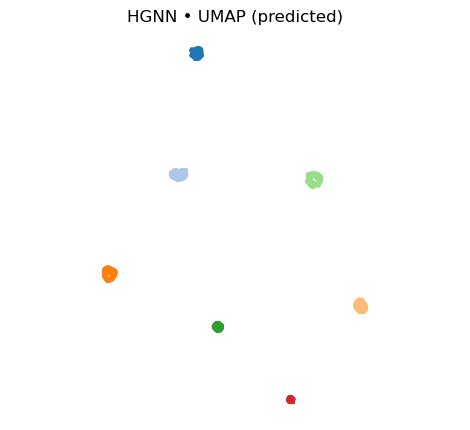

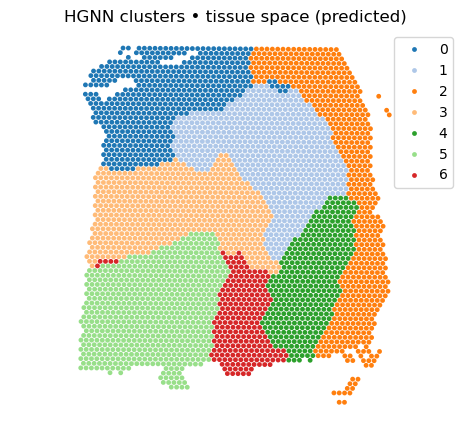

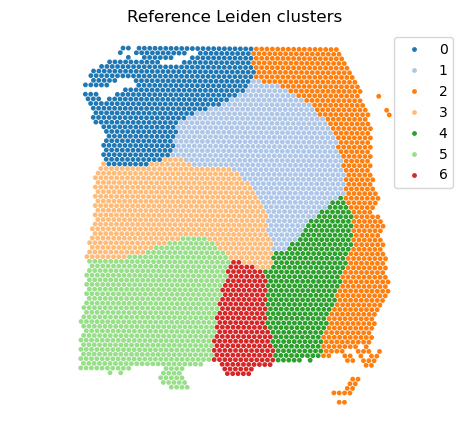

✓ cluster labels → Data/hgnn_clusters.npy


In [10]:
################################################################################
# 0.  Install once                                                             #
################################################################################
# pip install --quiet torch==2.3.1                                           \
#                 torch-sparse torch-scatter                                 \
#                 -f https://data.pyg.org/whl/torch-2.3.1+cpu.html
# pip install --quiet torch-geometric umap-learn scikit-learn matplotlib seaborn

################################################################################
# 1.  Load data                                                                #
################################################################################
import numpy as np, torch
import csv
from pathlib import Path
from torch_geometric.data import Data

# ── 1.1  labels (prefer nested) ──────────────────────────────────────────────
label_candidates = [
    Path('Data/spaformer_prepared/labels_nested.npy'),
    Path('Data/spaformer_prepared/leiden_labels.npy'),
]
labels = None
label_source = None
for cand in label_candidates:
    if cand.exists():
        labels = np.load(cand).astype('int64')
        label_source = cand
        break
if labels is None:
    raise FileNotFoundError('No label file found (checked labels_nested.npy, leiden_labels.npy).')

target_nodes = int(labels.shape[0])
use_nested = label_source.name == 'labels_nested.npy'
print(f'Using labels from {label_source}')

# ── 1.2  node features (prefer nested) ───────────────────────────────────────
feature_candidates = [
    Path('Data/spaformer_prepared/latent_nested.npy'),
    Path('Data/spaformer_prepared/latent_refined.npy'),
    Path('Data/spaformer_prepared/latent.npy'),
    Path('Data/spaformer_prepared/X.npy'),
]
X = None
feature_source = None
for cand in feature_candidates:
    if not cand.exists():
        continue
    arr = np.load(cand).astype('float32')
    if arr.shape[0] == target_nodes:
        X = arr
        feature_source = cand
        if cand.name == 'latent_nested.npy':
            use_nested = True
        break
if X is None:
    raise FileNotFoundError('No feature matrix found for HGNN (checked latent_nested, latent_refined, latent, X).')
if X.shape[0] != target_nodes:
    raise ValueError(f'Feature node count {X.shape[0]} does not match labels {target_nodes}.')
print(f'Using node features from {feature_source}')

coords_norm = np.load('Data/spaformer_prepared/C.npy').astype('float32')
coords_raw  = np.load('Data/spaformer_prepared/C_raw.npy').astype('float32')

# ── 1.3  hyperedges (prefer nested) ──────────────────────────────────────────
hyperedge_candidates = [
    Path('Data/hyperedge_index_nested.npy'),
    Path('Data/hyperedge_index.npy'),
]
H_idx = None
hyperedge_source = None
for cand in hyperedge_candidates:
    if cand.exists():
        H_idx = np.load(cand).astype('int64')
        hyperedge_source = cand
        if cand.name == 'hyperedge_index_nested.npy':
            use_nested = True
        break
if H_idx is None:
    raise FileNotFoundError('No hyperedge index found (checked hyperedge_index_nested.npy, hyperedge_index.npy).')
print(f'Using hyperedges from {hyperedge_source}')

if coords_norm.shape[0] != target_nodes or coords_raw.shape[0] != target_nodes:
    raise ValueError('Coordinate count mismatch with labels')
if H_idx.size == 0:
    raise ValueError('Hyperedge index is empty.')
node_total = int(H_idx[0].max()) + 1
if node_total != target_nodes:
    raise ValueError(f'Hypergraph node count {node_total} != labels {target_nodes}')

# pixel coordinates (use Visium mask + orientation)
positions_csv = Path('Data/positions.txt')
if positions_csv.exists():
    lookup = {}
    with positions_csv.open() as fh:
        reader = csv.reader(fh)
        for barcode, in_tissue, array_row, array_col, pxl_row, pxl_col in reader:
            row_val = float(pxl_row)
            col_val = float(pxl_col)
            flag = (in_tissue == '1')
            lookup[(row_val, col_val)] = (flag, col_val, row_val)
            lookup[(col_val, row_val)] = (flag, col_val, row_val)
    coords_xy = np.zeros_like(coords_raw)
    tissue_mask = np.zeros(coords_raw.shape[0], dtype=bool)
    for idx_pt, (a, b) in enumerate(coords_raw):
        key = (float(a), float(b))
        if key not in lookup:
            raise KeyError(f'Missing Visium coordinate {key}')
        flag, col_val, row_val = lookup[key]
        tissue_mask[idx_pt] = flag
        coords_xy[idx_pt] = (col_val, row_val)
else:
    tissue_mask = np.ones(coords_raw.shape[0], dtype=bool)
    coords_xy = coords_raw[:, ::-1]
coords_img = coords_xy - coords_xy.min(axis=0, keepdims=True)
np.save('Data/spaformer_prepared/in_tissue_mask.npy', tissue_mask)

# map labels to contiguous codes (ignore noise for supervision)
train_idx = labels != -1
train_labels = labels[train_idx]
if train_labels.size == 0:
    raise ValueError('All labels are -1 (noise); cannot train HGNN supervision.')
uniq_labels = np.unique(train_labels)
label_codes = np.searchsorted(uniq_labels, train_labels).astype('int64')
num_classes = int(len(uniq_labels))
label_codes_all = np.full(labels.shape[0], -1, dtype=int)
label_codes_all[train_idx] = label_codes

N, feat_dim = X.shape
print('nodes:', N, 'features:', feat_dim, 'hyper-edges:', H_idx.shape[1])
print('Classes (excl. noise):', num_classes)
print('Noise nodes:', int((labels == -1).sum()))

# ── 1.4  PyG Data object (node ↔ hyper-edge incidence) ───────────────────────
data = Data(
    x                = torch.from_numpy(X),          # node features  (N,F)
    hyperedge_index  = torch.from_numpy(H_idx),      # incidence      (2,|E|)
    pos              = torch.from_numpy(coords_norm) # normalized coords for models
)

################################################################################
# 2.  Simple HGNN built with HypergraphConv (2 layers)                         #
################################################################################
import torch.nn as nn
from torch_geometric.nn import HypergraphConv

class SimpleHGNN(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout=0.2):
        super().__init__()
        self.h1 = HypergraphConv(in_dim,  hidden)    # layer-1
        self.h2 = HypergraphConv(hidden, out_dim)    # layer-2
        self.act = nn.ReLU()
        self.dp  = nn.Dropout(dropout)

    def forward(self, data):
        x = self.act(self.h1(data.x, data.hyperedge_index))
        x = self.dp(x)
        z = self.h2(x, data.hyperedge_index)
        return z                                     # (N, out_dim)

model = SimpleHGNN(in_dim=feat_dim, hidden=256, out_dim=256, dropout=0.1)
classifier = nn.Linear(256, num_classes)
print(model)

################################################################################
# 3.  Label-consistency training                                               #
################################################################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data   = data.to(device)
model  = model.to(device)
classifier = classifier.to(device)
label_tensor = torch.from_numpy(label_codes).to(device)
train_idx_t = torch.from_numpy(train_idx).to(device)

# class-weighted loss to reduce collapse
class_counts = np.bincount(label_codes, minlength=num_classes).astype('float32')
class_weights = class_counts.sum() / np.clip(class_counts, 1.0, None)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.from_numpy(class_weights).to(device)

opt     = torch.optim.Adam(
            list(model.parameters()) + list(classifier.parameters()),
            lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

epochs = 200
patience = 20
best_acc = -1.0
best_state = None
no_improve = 0

for epoch in range(1, epochs+1):
    model.train(); classifier.train()
    opt.zero_grad()
    z      = model(data)
    logits = classifier(z)
    loss   = criterion(logits[train_idx_t], label_tensor)
    loss.backward(); opt.step()

    pred = logits.argmax(dim=1)
    pred_train = pred[train_idx_t]
    acc = (pred_train == label_tensor).float().mean().item() * 100
    if acc > best_acc + 1e-3:
        best_acc = acc
        best_state = {
            'model': model.state_dict(),
            'classifier': classifier.state_dict(),
        }
        no_improve = 0
    else:
        no_improve += 1

    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:3d}/{epochs}   loss {loss.item():.4f}   acc {acc:.2f}%")

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch} (best acc {best_acc:.2f}%)')
        break

if best_state is not None:
    model.load_state_dict(best_state['model'])
    classifier.load_state_dict(best_state['classifier'])

# ── 3.1  save node embeddings & predictions ─────────────────────────────────
model.eval(); classifier.eval()
with torch.no_grad():
    Z_torch = model(data)
    logits  = classifier(Z_torch)
    pred_codes = logits.argmax(dim=1).cpu().numpy()
    Z = Z_torch.cpu().numpy()

pred_labels = uniq_labels[pred_codes]

suffix = '_nested' if use_nested else ''
np.save(f'Data/hgnn_embeddings{suffix}.npy', Z)
np.save(f'Data/hgnn_predictions{suffix}.npy', pred_labels)
print(f'✓ HGNN embedding saved → Data/hgnn_embeddings{suffix}.npy')
print(f'✓ HGNN predicted labels → Data/hgnn_predictions{suffix}.npy')

################################################################################
# 4.  Visualise                                                               #
################################################################################
import umap, seaborn as sns, matplotlib.pyplot as plt

palette = sns.color_palette('tab20', num_classes)
coords_plot = coords_img[tissue_mask]
pred_plot = pred_codes[tissue_mask]
ref_plot = label_codes_all[tissue_mask]

# 4.1  UMAP view of the embedding space coloured by HGNN predictions
Z_umap = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=0).fit_transform(Z)
plt.figure(figsize=(4.8,4.4))
sns.scatterplot(x=Z_umap[:,0], y=Z_umap[:,1], hue=pred_codes, palette=palette,
                s=8, linewidth=0, legend=False)
plt.axis('equal'); plt.axis('off'); plt.title('HGNN • UMAP (predicted)')
plt.tight_layout(); plt.show()

# 4.2  clusters back on the tissue coordinates (HGNN prediction)
plt.figure(figsize=(4.8,4.4))
sns.scatterplot(x=coords_plot[:,0], y=coords_plot[:,1], hue=pred_plot, palette=palette,
                s=12, linewidth=0, legend='full')
plt.gca().invert_yaxis()
plt.axis('equal'); plt.axis('off'); plt.title('HGNN clusters • tissue space (predicted)')
plt.tight_layout(); plt.show()

# 4.3  reference clusters for comparison (noise shown as extra color)
if (ref_plot == -1).any():
    ref_palette = sns.color_palette('tab20', num_classes + 1)
    ref_plot_vis = np.where(ref_plot == -1, num_classes, ref_plot)
else:
    ref_palette = palette
    ref_plot_vis = ref_plot

plt.figure(figsize=(4.8,4.4))
sns.scatterplot(x=coords_plot[:,0], y=coords_plot[:,1], hue=ref_plot_vis, palette=ref_palette,
                s=12, linewidth=0, legend='full')
plt.gca().invert_yaxis()
plt.axis('equal'); plt.axis('off'); plt.title('Reference clusters')
plt.tight_layout(); plt.show()

np.save(f'Data/hgnn_clusters{suffix}.npy', pred_labels)
print(f'✓ cluster labels → Data/hgnn_clusters{suffix}.npy')
